<div align="center">

<img src="../assets/logo.png" width="400">

# AUDITORÍA A LA CONTRATACIÓN PÚBLICA  
## Auditoria a la contratacion publica Plataforma SIA Observa – Vigencia 2025


**Entidad auditada:** 53 Sujetos de control 

**Tipo de análisis:** Auditoria basada en datos 

**Realizado por:** Wilmer Fidel Restrepo Orrego 
 
**Fecha de creacion:** 2026

**Fuente de los datos:** Plataforma Sia Observa 

</div>

Se cargan las librerías necesarias, se configuran las rutas del proyecto y se vinculan los módulos de limpieza y análisis de datos.

Se inicializa el entorno de trabajo y se muestra:

Información del sistema (SO, Python, fecha)
Versiones de las librerías
Rutas principales del proyecto

In [12]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
import seaborn as sns

from IPython.display import display,Markdown




sys.path.append(os.path.abspath(os.path.join('..')))
from src.cleaners import aplicar_tipos_datos, TIPOS_BASICO, TIPOS_EXTENDIDO, estandarizar_modalidades,estandarizar_causales,estandarizar_recursos_v2

from src import (
    setup_environment, RAW_DATA_PATH, BASE_DIR,
    aplicar_tipos_datos, TIPOS_BASICO, TIPOS_EXTENDIDO,
    formato_moneda_co, formato_miles_co,
    calcular_alertas_adicion,calcular_duracion_vigencia
)


from src.environment import get_environment_info
from src.system import get_library_versions

setup_environment()
env = get_environment_info()
versions = get_library_versions()


print("""
AUDITORIA A LA CONTRATACION PUBLICA VIGENCIA 2025 -PLATAFORMA SIA OBSERVA
========================================================================
- Entorno configurado correctamente
- Los módulos de análisis y limpieza fueron vinculados
- Sistema listo para procesar datos de auditoria
""")

print(f"""
INFORMACION SOBRE EL ENTORNO DE DESARROLLO
=========================================================================
- Sistema operativo : {env['os']}  
- Version Python    : {env['python']}  
- Kernel            : {env['kernel']}  
- Fecha ejecucion   : {env['timestamp']}
""")

print("""
VERSION DE LAS LIBRERIAS UTILIZADAS EN EL PROYECTO
==========================================================================      
""")
for lib, version in versions.items():
    print (f"{lib.capitalize():<12}:{version}")


display(Markdown (f"""
Rutas del proyecto
===========================================================================
Base del proyecto:{BASE_DIR}  
Ubicacion de las muestras de auditoria:{RAW_DATA_PATH}
"""))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

AUDITORIA A LA CONTRATACION PUBLICA VIGENCIA 2025 -PLATAFORMA SIA OBSERVA
- Entorno configurado correctamente
- Los módulos de análisis y limpieza fueron vinculados
- Sistema listo para procesar datos de auditoria


INFORMACION SOBRE EL ENTORNO DE DESARROLLO
- Sistema operativo : Linux 6.17.0-22-generic  
- Version Python    : 3.12.3  
- Kernel            : CPython  
- Fecha ejecucion   : 2026-05-11 14:39:48


VERSION DE LAS LIBRERIAS UTILIZADAS EN EL PROYECTO

Pandas      :3.0.0
Numpy       :2.4.2
Matplotlib  :3.10.8
Plotly      :6.5.2
Seaborn     :0.13.2



Rutas del proyecto
===========================================================================
Base del proyecto:/home/wilo/Escritorio/auditoria_sia  
Ubicacion de las muestras de auditoria:/home/wilo/Escritorio/auditoria_sia/data/raw


# Proceso ETL: Limpieza y Preparación de Datos

En este bloque se ejecuta el proceso de Extracción, Transformación y Carga (ETL). El objetivo es convertir los reportes crudos de la plataforma SIA OBSERVA en un conjunto de datos estandarizado y optimizado para el análisis de auditoría.


Ingesta y Tipado: Carga de archivos y conversión estricta de formatos (fechas y números).
Normalización: Homologación de catálogos (modalidades, causales y recursos) y cálculo de métricas base.
Aseguramiento (QA): Verificación de integridad, control de valores nulos y monitoreo de eficiencia en memoria.

In [13]:
def procesar_pipeline_auditoria(df):

    df = estandarizar_modalidades(df)
    df = estandarizar_causales(df)
    df = estandarizar_recursos_v2(df)
    df = calcular_duracion_vigencia(df)

    return df


def realizar_qa_senior(df, nombre):

    print(f"REPORTE TÉCNICO SOBRE INTEGRIDAD: {nombre}")
    print(f"{'='*50}")

    nulos = df.isna().sum()
    reporte_nulos = nulos[nulos > 0]

    memoria_mb = df.memory_usage(deep=True).sum() / (1024**2)

    if reporte_nulos.empty:
        print("No se detectan valores nulos.")
    else:
        print("COLUMNAS QUE CONTIENEN VALORES NULOS:")
        print(reporte_nulos.sort_values(ascending=False))

    print(f"\n MÉTRICAS DE CARGA:")
    print(f"- Total de filas: {len(df):,}")
    print(f"- Total de columnas:  {len(df.columns)}")
    print(f"- Uso de memoria:     {memoria_mb:.2f} MB")
    print(f"{'='*50}\n")


print("Cargando archivos desde RAW_DATA_PATH...")


df_basico = procesar_pipeline_auditoria(
    aplicar_tipos_datos(
        pd.read_excel(os.path.join(RAW_DATA_PATH, "Informe_Basico.xlsx")), TIPOS_BASICO
    )
)

df_ext = procesar_pipeline_auditoria(
    aplicar_tipos_datos(
        pd.read_excel(os.path.join(RAW_DATA_PATH, "Informe_Extendido.xlsx")),
        TIPOS_EXTENDIDO,
    )
)

print(f" PROCESAMIENTO COMPLETADO | {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


realizar_qa_senior(df_basico, "INFORME BÁSICO")
realizar_qa_senior(df_ext, "INFORME EXTENDIDO")


print("VISTA PREVIA DE DATOS NORMALIZADOS")
display(df_basico.head(3))
display(df_ext.head(3))

Cargando archivos desde RAW_DATA_PATH...
 PROCESAMIENTO COMPLETADO | 2026-05-11 14:40:07
REPORTE TÉCNICO SOBRE INTEGRIDAD: INFORME BÁSICO
COLUMNAS QUE CONTIENEN VALORES NULOS:
FECHA_TERMINACION_AMPLIADA    10252
NIT_1                             3
NOMBRE                            3
TIPO                              3
dtype: int64

 MÉTRICAS DE CARGA:
- Total de filas: 14,199
- Total de columnas:  25
- Uso de memoria:     13.21 MB

REPORTE TÉCNICO SOBRE INTEGRIDAD: INFORME EXTENDIDO
No se detectan valores nulos.

 MÉTRICAS DE CARGA:
- Total de filas: 14,138
- Total de columnas:  33
- Uso de memoria:     23.44 MB

VISTA PREVIA DE DATOS NORMALIZADOS


,TIPO_DE_ENTIDAD,NIT,ENTIDAD,VIGENCIA,CODIGO_CONTRATO,VALOR_INICIAL_CONTRATO,ADICIONES,LIBERACIONES,VALOR_VIGENTE,FECHA_SUSCRIPCION,FECHA_ACTA_DE_INICIO,FECHA_TERMINACION,TIEMPO_EJECUCION,MODALIDAD_CONTRATACION,CAUSAL_CONTRATO,TIPO_CONTRATO,FECHA_CREACION,FECHA_TERMINACION_AMPLIADA,NIT_1,NOMBRE,TIPO,ESTADO_CONTRATO,MODALIDAD_ESTANDAR,CAUSAL_ESTANDAR,DURACION_REAL
0,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-01-2025,"17,676,000.00",0.00,0.00,"17,676,000.00",2025-01-01,2025-01-01,2025-12-31,364,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,2025-01-31,NaT,24547202,MARIA LILIANA MONTES HOYOS,Contratista,RENDIDO,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,364
1,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-02-2025,"8,846,800.00",0.00,0.00,"8,846,800.00",2025-01-01,2025-01-01,2025-12-31,364,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,2025-01-31,NaT,900010878,GRUPO METRO Y CIA. LTDA,Contratista,RENDIDO,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,364
2,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-03-2025,"22,176,000.00",0.00,0.00,"22,176,000.00",2025-01-02,2025-01-02,2025-12-31,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,2025-01-31,NaT,1088290219,DIANA MARCELA RIOS AGUIRRE,Contratista,RENDIDO,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,363


,TIPO_DE_ENTIDAD,NIT,ENTIDAD,VIGENCIA,CODIGO_CONTRATO,OBJETO_CONTRATO,FECHA_SUSCRIPCION,FECHA_ACTA_DE_INICIO,FECHA_TERMINACION,TIEMPO_EJECUCION,VALOR_INICIAL_CONTRATO,ADICIONES,LIBERACIONES,VALOR_VIGENTE,MODALIDAD_CONTRATACION,CAUSAL_CONTRATO,TIPO_CONTRATO,NIT_1,NOMBRE,TIPO,NIT_2,NOMBRE_1,TIPO_1,NOMBRE_DEL_RUBRO,APROPIACION_INICIAL,ORIGEN_RECURSOS,CDPS,RPS,FECHA_CREACION,MODALIDAD_ESTANDAR,CAUSAL_ESTANDAR,ORIGEN_RECURSOS_ESTANDAR,DURACION_REAL
0,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-01-2025,ARRENDAMIENTO DE INMUEBLE CON DESTINACION COME...,2025-01-01,2025-01-01,2025-12-31,364,"17,676,000.00",0.00,0.00,"17,676,000.00",CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,24547202,MARIA LILIANA MONTES HOYOS,Contratista,1088332330,JORGE WILLIAM GONZALEZ TAMAYO,Interno,SERVICIOS FINANCIEROS Y SERVICIOS CONEXOS; SER...,"68,266,800.00",RECURSOS PROPIOS,20250001,20250001,2025-01-31,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,RECURSOS PROPIOS,364
1,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-02-2025,"CONTRATAR LA IMPLEMENTACION, PUESTA EN FUNCION...",2025-01-01,2025-01-01,2025-12-31,364,"8,846,800.00",0.00,0.00,"8,846,800.00",CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,900010878,GRUPO METRO Y CIA. LTDA,Contratista,1088332330,JORGE WILLIAM GONZALEZ TAMAYO,Interno,PAQUETES DE SOFTWARE,"9,072,000.00",RECURSOS PROPIOS,20250003,20250003,2025-01-31,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,RECURSOS PROPIOS,364
2,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-03-2025,PRESTAR EL SERVICIO PROFESIONAL EN EL CARGO DE...,2025-01-02,2025-01-02,2025-12-31,363,"22,176,000.00",0.00,0.00,"22,176,000.00",CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,1088290219,DIANA MARCELA RIOS AGUIRRE,Contratista,1088332330,JORGE WILLIAM GONZALEZ TAMAYO,Interno,SERVICIOS PRESTADOS A LAS EMPRESAS Y SERVICIOS...,"171,903,986.00",RECURSOS PROPIOS,20250005,20250003,2025-01-31,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,RECURSOS PROPIOS,363


# Generación de Entregables y Origen para Power BI

En este bloque se consolidan los resultados del proceso ETL en la carpeta de datos procesados (`/data/processed`). Estos archivos constituyen la fuente de verdad que será consumida por el tablero de control en Power BI.

Optimizaciones para Analítica y Visualización:

Compatibilidad de Power Query: Se generan archivos CSV con codificación `utf-8-sig` y separador `;`, optimizados para una carga limpia en Power BI sin errores de delimitación o caracteres.

Normalización de Fechas: Las columnas cronológicas se exportan en formato ISO (`YYYY-MM-DD`), facilitando la creación de tablas de calendario y jerarquías temporales en DAX.

Integridad de Datos: El uso de copias temporales (`.copy()`) garantiza que el formato de exportación para consumo externo no altere los tipos de datos lógicos dentro del entorno de Python.

In [ ]:
from src.system import exportar_para_bi
import os

print("Exportando archivos limpios para analisis de datos con Power BI")

PROCESSED_DATA_PATH = os.path.join("..", "data", "processed")


archivos_a_exportar = {
    "Informe_Basico_Procesado": df_basico,
    "Informe_Extendido_Procesado": df_ext,
}

try:
    exportar_para_bi(archivos_a_exportar, PROCESSED_DATA_PATH)
    print(f"\n Ruta de los archivos: {os.path.abspath(PROCESSED_DATA_PATH)}")
except Exception as e:
    print(f"Ha ocurrido un error en exportación: {e}")

Exportando archivos limpios para analisis de datos con Power BI
Exportado: Informe_Basico_Procesado.csv
Exportado: Informe_Extendido_Procesado.csv

 Ruta de los archivos: /home/wilo/Escritorio/auditoria_sia/data/processed


# Resumen General de Contratos

En esta sección se realiza el cálculo de indicadores generales de la muestra contractual analizada, incluyendo:

-Cantidad total de contratos reportados.
-Valor total acumulado de la contratación.
-Valor promedio de los contratos.
-Identificación del contrato de mayor cuantía dentro de la muestra.



In [ ]:
from src.analysis import calcular_resumen_contratos

resumen = calcular_resumen_contratos(df_ext)

print(f"--- RESULTADOS DE AUDITORÍA ---")
print(f" Total Contratos Reportados: {resumen['cantidad']}")
print(f" Valor Total de los Contratos Reportados: ${resumen['total_suma']:,.2f}")
print(f" Valor Promedio de los Contratos: ${resumen['promedio']:,.2f}")
print("-" * 40)
print(f" CONTRATO DE MAYOR VALOR EN LA MUESTRA ")
print(f" Entidad: {resumen['mayor_contrato']['entidad']}")
print(f" Código de Contrato: {resumen['mayor_contrato']['codigo']}")
print(f" Valor del Contrato: ${resumen['mayor_contrato']['valor']:,.2f}")
print(f" objeto Contractual: {resumen['mayor_contrato']['objeto']}")

--- RESULTADOS DE AUDITORÍA ---
 Total Contratos Reportados: 14138
 Valor Total de los Contratos Reportados: $1,329,649,976,891.29
 Valor Promedio de los Contratos: $94,047,954.23
----------------------------------------
 CONTRATO DE MAYOR VALOR EN LA MUESTRA 
 Entidad: EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA
 Código de Contrato: 307-2025
 Valor del Contrato: $98,405,360,859.00
 objeto Contractual: CONSTRUCCION DE LA ESTRUCTURA DEL EDIFICO DE ALTA COMPLEJIDAD DEL PROYECTO HOSPITAL REGIONAL DE ALTA COMPLEJIDAD EN EL DEPARTAMENTO DE RISARALDA


# Contratación por Tipo de Entidad

En esta sección se realiza un análisis consolidado de la contratación según el tipo de entidad, identificando:

-Cantidad de contratos registrados por cada tipo de entidad.
-Valor total contratado asociado a cada categoría.
-Participación de las entidades dentro del volumen general de contratación.


In [ ]:
from src.analysis import contratacion_por_tipo_entidad

df_por_entidad = contratacion_por_tipo_entidad(df_ext)

print("ANÁLISIS DE CONTRATOS POR TIPO DE ENTIDAD")
display(df_por_entidad)

ANÁLISIS DE CONTRATOS POR TIPO DE ENTIDAD


,TIPO_DE_ENTIDAD,CANTIDAD_CONTRATOS,VALOR_TOTAL
5,ENTIDADES TERRITORIALES,7609,"661,975,700,550.35"
4,EMPRESAS SOCIALES DEL ESTADO,4464,"382,860,344,191.53"
3,EMPRESAS INDUSTRIALES Y COMERCIALES DEL ESTADO,569,"181,785,600,313.00"
2,EMPRESA DE SERVICIOS PUBLICOS,942,"84,637,736,788.55"
0,AREAS METROPOLITANAS,361,"14,254,334,544.86"
6,ESTABLECIMIENTO PUBLICOS,123,"2,739,627,498.00"
1,ASOCIACION ENTRE ENTIDADES PUBLICAS,49,"984,830,573.00"
7,SOCIEDADES DE ECONOMIA MIXTA,21,"411,802,432.00"


# Visualización de Contratación por Tipo de Entidad

En esta sección se genera una gráfica comparativa que permite visualizar el comportamiento de la contratación según el tipo de entidad pública.

La visualización presenta:

-Valor total contratado por cada tipo de entidad.
-Cantidad de contratos registrados.
-Comparación proporcional entre categorías de entidades.

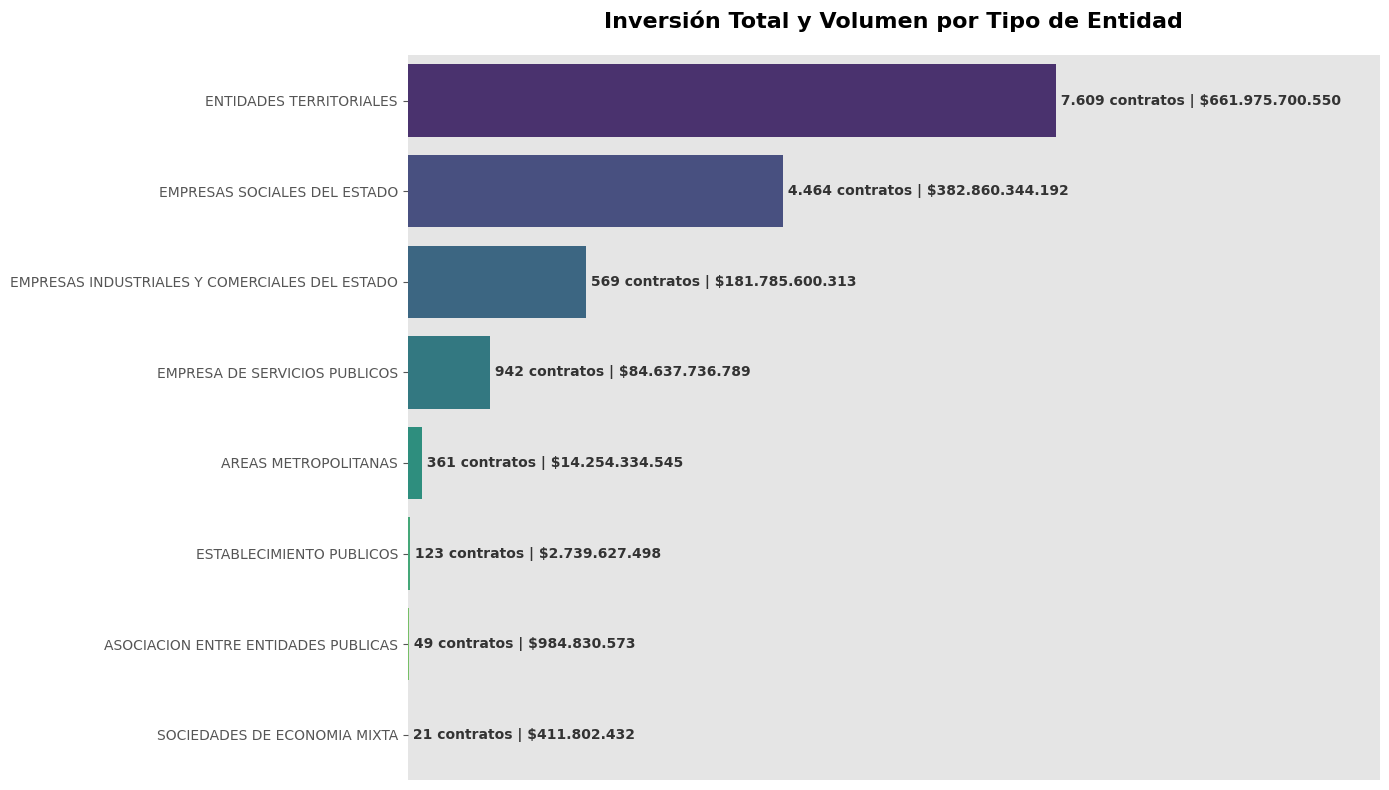

In [ ]:
df_grafica = contratacion_por_tipo_entidad(df_ext)


plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df_grafica,
    x="VALOR_TOTAL",
    y="TIPO_DE_ENTIDAD",
    palette="viridis",
    hue="TIPO_DE_ENTIDAD",
    legend=False,
)

for i, bar in enumerate(ax.patches):

    monto = df_grafica.iloc[i]["VALOR_TOTAL"]
    cantidad = df_grafica.iloc[i]["CANTIDAD_CONTRATOS"]

    label_text = f" {int(cantidad):,} contratos | ${monto:,.0f}".replace(",", ".")

    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        label_text,
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#333333",
    )


plt.title(
    "Inversión Total y Volumen por Tipo de Entidad",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("")
plt.ylabel("")
plt.xticks([])


plt.xlim(0, df_grafica["VALOR_TOTAL"].max() * 1.5)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# Participación por Tipo de Contrato

En esta sección se analiza la distribución de la contratación según el tipo de contrato registrado en la muestra.

El análisis incluye:

-Cantidad de contratos por modalidad contractual.
-Valor total asociado a cada tipo de contrato.
-Porcentaje de participación frente al total de contratos analizados.

In [24]:
from src.analysis import analizar_por_tipo_contrato

df_tipo_contrato = analizar_por_tipo_contrato(df_ext)

print(" TABLA RESUMEN: PARTICIPACIÓN POR TIPO DE CONTRATO")

df_estilo = df_tipo_contrato.copy()
df_estilo["VALOR_TOTAL"] = (
    df_estilo["VALOR_TOTAL"].map("${:,.0f}".format).str.replace(",", ".")
)
df_estilo["PORCENTAJE_PARTICIPACION"] = df_estilo["PORCENTAJE_PARTICIPACION"].map(
    "{:.2f}%".format
)
display(df_estilo)

 TABLA RESUMEN: PARTICIPACIÓN POR TIPO DE CONTRATO


,TIPO_CONTRATO,CANTIDAD,VALOR_TOTAL,PORCENTAJE_PARTICIPACION
5,CONTRATO DE PRESTACION DE SERVICIOS,9196,$565.993.004.467,65.04%
0,APOYO A LA GESTION,2406,$63.520.253.016,17.02%
9,SUMINISTRO,1716,$225.696.627.015,12.14%
6,CONVENIOS,293,$123.619.518.540,2.07%
1,COMPRAVENTA,215,$38.694.321.259,1.52%
4,CONTRATO DE OBRA,205,$286.857.201.812,1.45%
2,CONTRATO DE CONSULTORIA,51,$7.974.367.759,0.36%
3,CONTRATO DE INTERVENTORIA,50,$17.095.124.210,0.35%
7,DERIVADOS DE LA AUTONOMIA DE LA VOLUNTAD,5,$110.915.480,0.04%
8,ENCARGOS FIDUCIARIOS,1,$88.643.334,0.01%


# Distribución Porcentual por Tipo de Contrato

En esta sección se presenta una visualización gráfica de la participación porcentual de cada tipo de contrato dentro de la muestra analizada.

La gráfica permite identificar:

-Las modalidades contractuales con mayor participación.
-La distribución relativa de los contratos según su tipo.
-La concentración contractual dentro del universo analizado.

Esta representación facilita la interpretación visual de la composición contractual reportada.

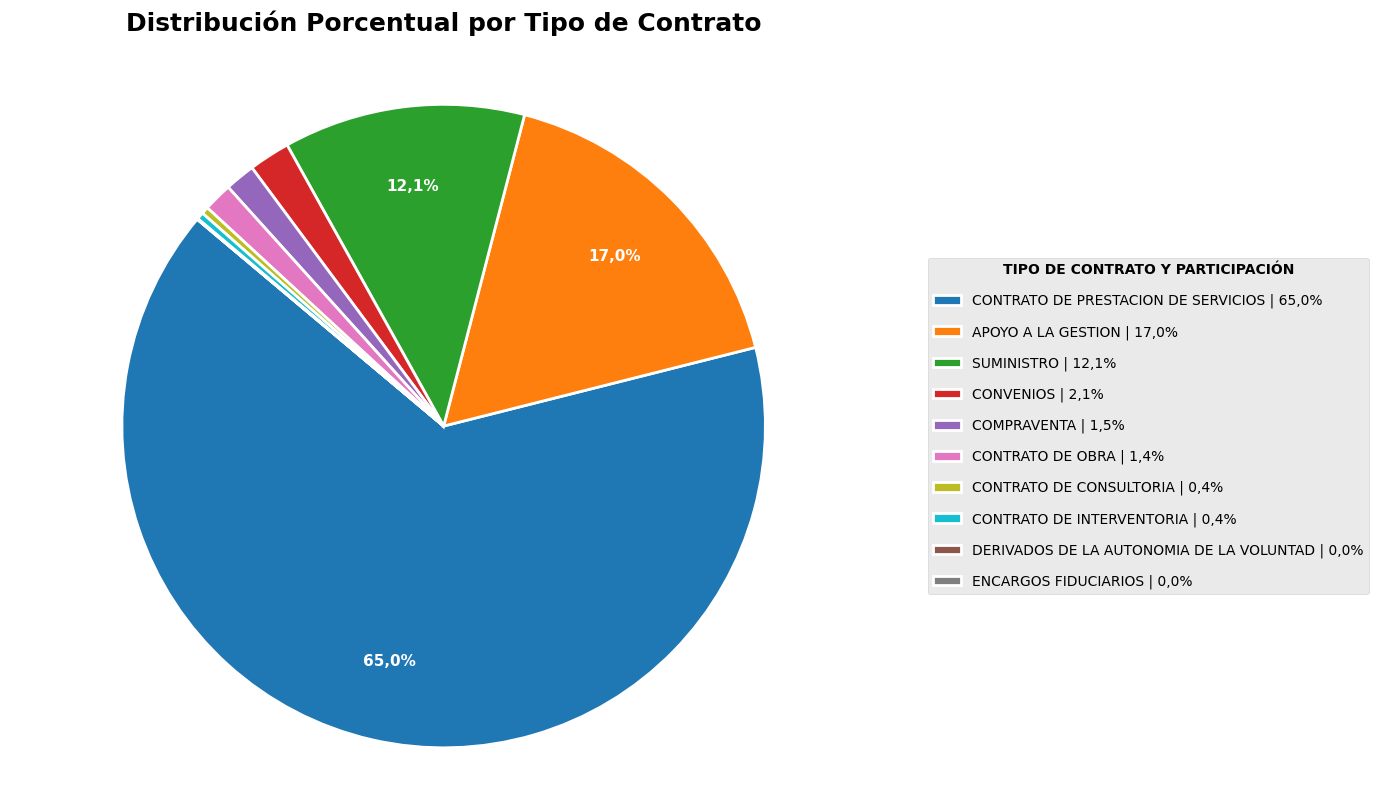

In [ ]:
from src.analysis import analizar_por_tipo_contrato

df_tipo_contrato = analizar_por_tipo_contrato(df_ext)

import matplotlib.pyplot as plt

df_plot = df_tipo_contrato.sort_values("PORCENTAJE_PARTICIPACION", ascending=False)

colores_vivos = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#e377c2",
    "#bcbd22",
    "#17becf",
    "#8c564b",
    "#7f7f7f",
]

fig, ax = plt.subplots(figsize=(14, 8))

wedges, texts, autotexts = ax.pie(
    df_plot["PORCENTAJE_PARTICIPACION"],
    autopct=lambda p: f"{p:.1f}%".replace(".", ",") if p > 4 else "",
    startangle=140,
    colors=colores_vivos[: len(df_plot)],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)

plt.setp(autotexts, size=11, weight="bold", color="white")


labels_tabla = [
    f"{row['TIPO_CONTRATO']} | {row['PORCENTAJE_PARTICIPACION']:.1f}%".replace(".", ",")
    for _, row in df_plot.iterrows()
]


leyenda = ax.legend(
    wedges,
    labels_tabla,
    title="TIPO DE CONTRATO Y PARTICIPACIÓN",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=10,
    frameon=True,
    edgecolor="#CCCCCC",
    labelspacing=1.2,
)
leyenda.get_title().set_fontweight("bold")

plt.title(
    "Distribución Porcentual por Tipo de Contrato",
    fontsize=18,
    fontweight="bold",
    pad=30,
)
ax.axis("equal")
plt.tight_layout()
plt.show()

# Análisis por Modalidad de Contratación

En esta sección se analiza la distribución de los contratos según la modalidad de contratación utilizada por las entidades reportantes.

El análisis incluye:

-Cantidad de contratos por modalidad.
-Valor total contratado asociado a cada modalidad.
-Participación porcentual dentro del total de contratos analizados.



In [ ]:
from src.analysis import analizar_por_modalidad

df_modalidad = analizar_por_modalidad(df_ext)
display(df_modalidad)

,MODALIDAD_ESTANDAR,CANTIDAD,VALOR_TOTAL,%_PARTICIPACION
6,REGIMEN ESPECIAL,4948,"543,391,773,822.29",35.00
1,CONTRATACION DIRECTA,8092,"473,579,940,385.36",57.24
4,LICITACIONES PUBLICAS,70,"160,933,101,870.00",0.50
7,SELECCION ABREVIADA,129,"91,458,854,926.33",0.91
3,INVITACION CERRADA,316,"28,144,333,424.14",2.24
5,MINIMA CUANTIA,564,"14,967,826,603.52",3.99
2,CONVOCATORIA PUBLICA - DECRETO 092/2017,10,"12,611,254,873.00",0.07
0,CONCURSO DE MERITOS,9,"4,562,890,986.65",0.06


# Distribución por Origen de Recursos

En esta sección se analiza la distribución de la inversión contractual según el origen de los recursos utilizados en la contratación reportada.

El análisis incluye:

-Cantidad de contratos por fuente de financiación.
-Valor total contratado asociado a cada origen de recursos.
-Participación porcentual de la inversión dentro del total analizado.



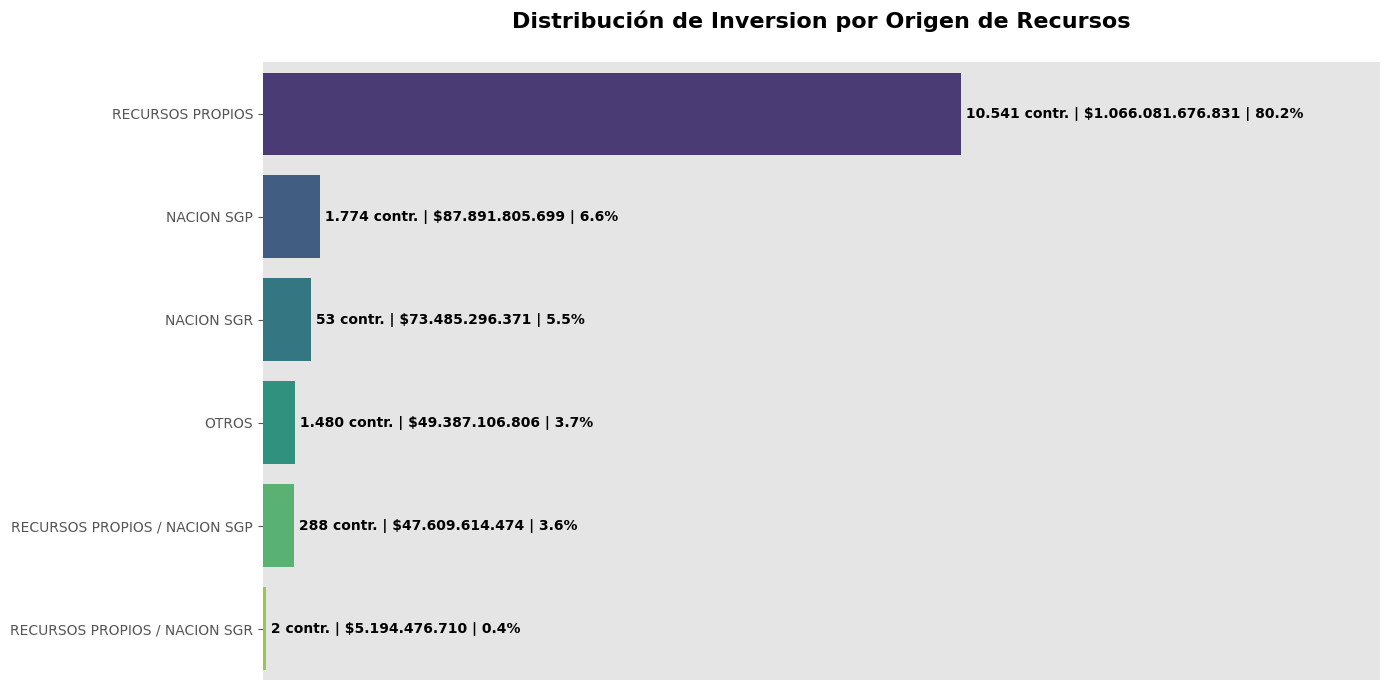


📋 RESUMEN FINANCIERO POR FUENTE DE FINANCIACIÓN:


,ORIGEN_RECURSOS_ESTANDAR,CANTIDAD_CONTRATOS,VALOR_TOTAL,%_INVERSION
3,RECURSOS PROPIOS,10541,$ 1.066.081.676.831,80.18%
0,NACION SGP,1774,$ 87.891.805.699,6.61%
1,NACION SGR,53,$ 73.485.296.371,5.53%
2,OTROS,1480,$ 49.387.106.806,3.71%
4,RECURSOS PROPIOS / NACION SGP,288,$ 47.609.614.474,3.58%
5,RECURSOS PROPIOS / NACION SGR,2,$ 5.194.476.710,0.39%


In [ ]:
from src.analysis import analizar_por_origen_recursos

df_recursos = analizar_por_origen_recursos(df_ext)

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_recursos,
    x="VALOR_TOTAL",
    y="ORIGEN_RECURSOS_ESTANDAR",
    palette="viridis",
    hue="ORIGEN_RECURSOS_ESTANDAR",
    legend=False,
)


for i, bar in enumerate(ax.patches):
    monto = df_recursos.iloc[i]["VALOR_TOTAL"]
    cant = df_recursos.iloc[i]["CANTIDAD_CONTRATOS"]
    porc = df_recursos.iloc[i]["%_INVERSION"]
    label = f" {int(cant):,} contr. | ${monto:,.0f} | {porc:.1f}%".replace(",", ".")
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontweight="bold",
        fontsize=10,
    )

plt.title(
    "Distribución de Inversion por Origen de Recursos",
    fontsize=16,
    fontweight="bold",
    pad=25,
)
plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.xlim(0, df_recursos["VALOR_TOTAL"].max() * 1.6)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


print("\n RESUMEN  POR FUENTE DE FINANCIACIÓN:")
tabla_fuentes = (
    df_recursos.style.format(
        {
            "VALOR_TOTAL": lambda x: f"$ {x:,.0f}".replace(",", "."),
            "%_INVERSION": "{:.2f}%",
        }
    )
    .background_gradient(subset=["%_INVERSION"], cmap="Greens")
    .set_properties(**{"text-align": "left"})
)
display(tabla_fuentes)

# Ranking de Entidades por Monto Contratado

En esta sección se presenta un ranking de las entidades con mayor valor contratado dentro de la muestra analizada.

El análisis incluye:

-Valor total contratado por entidad.
-Cantidad de contratos registrados.
-Comparación entre entidades según el nivel de recursos comprometidos.



# Tabla Ranking de Entidades Contratantes

En esta sección se presenta una tabla consolidada con las entidades que registran los mayores montos de contratación dentro de la muestra analizada.

La tabla incluye:

-Nombre de la entidad contratante.
-Cantidad de contratos registrados.
-Valor total contratado por entidad.



In [ ]:
from src.analysis import analizar_ranking_entidades

df_ranking = analizar_ranking_entidades(df_ext)

print("RANKING DE ENTIDADES POR MONTO CONTRATADO")
print("-" * 50)


ranking_estilizado = (
    df_ranking.head(20)
    .style.format(
        {
            "VALOR_TOTAL": lambda x: f"$ {x:,.0f}".replace(",", "."),
            "CANTIDAD_CONTRATOS": "{:,}",
        }
    )
    .background_gradient(subset=["VALOR_TOTAL"], cmap="YlOrRd")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1a5276"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                ],
            }
        ]
    )
)
display(ranking_estilizado)

RANKING DE ENTIDADES POR MONTO CONTRATADO
--------------------------------------------------


,ENTIDAD,CANTIDAD_CONTRATOS,VALOR_TOTAL
32,GOBERNACION DE RISARALDA,"3,793",$ 476.002.998.528
29,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,396,$ 171.631.847.052
36,HOSPITAL SAN JORGE DE PEREIRA,"1,089",$ 169.863.209.720
47,HOSPITAL SANTA MONICA,551,$ 76.835.144.340
10,ALCALDIA DE SANTA ROSA DE CABAL,"1,017",$ 43.507.767.550
40,HOSPITAL SAN PEDRO Y SAN PABLO LA VIRGINIA,333,$ 29.756.312.199
8,ALCALDIA DE PUEBLO RICO,459,$ 29.127.970.893
44,HOSPITAL SAN VICENTE DE PAUL DE SANTA ROSA DE CABAL,386,$ 22.686.370.229
7,ALCALDIA DE MISTRATO,411,$ 18.021.949.123
26,EMPRESA DE SERVICIOS PUBLICOS DE SANTA ROSA DE CABAL,106,$ 16.375.009.032


# Identificación de Contratos con Adiciones Superiores al 50%

En esta sección se realiza una validación sobre los contratos que presentan adiciones presupuestales respecto al valor inicial contratado.

El análisis permite:

- Identificar contratos con incrementos significativos en su valor.
- Calcular el porcentaje de adición frente al valor inicial.
- Detectar contratos que superan el umbral del 50% de adición.


In [ ]:
from src.analysis import calcular_alertas_adicion

df_con_alertas = calcular_alertas_adicion(df_ext)


sospechosos = df_con_alertas[df_con_alertas["ESTADO_ADICION"] == "ALERTA ROJA"].copy()

print(f"Se detectaron {len(sospechosos)} contratos con adiciones superiores al 50%.")

if not sospechosos.empty:
    print("\n TABLA RESUMEN: CONTRATOS QUE SUPERAN EL 50% DE ADICIÓN")

    reporte_final = sospechosos[
        [
            "ENTIDAD",
            "CODIGO_CONTRATO",
            "VALOR_INICIAL_CONTRATO",
            "ADICIONES",
            "PORCENTAJE_ADICION",
        ]
    ].sort_values(by="PORCENTAJE_ADICION", ascending=False)

    display(
        reporte_final.style.format(
            {
                "VALOR_INICIAL_CONTRATO": "$ {:,.0f}",
                "ADICIONES": "$ {:,.0f}",
                "PORCENTAJE_ADICION": "{:.2f}%",
            }
        ).background_gradient(subset=["PORCENTAJE_ADICION"], cmap="Reds")
    )
else:
    print("No hay contratos con adicion mayor al 50%.")

    con_algo = df_con_alertas[df_con_alertas["PORCENTAJE_ADICION"] > 0]
    print(
        f"Nota: Se encontraron {len(con_algo)} contratos con adiciones menores al 50%."
    )

Se detectaron 294 contratos con adiciones superiores al 50%.

 TABLA RESUMEN: CONTRATOS QUE SUPERAN EL 50% DE ADICIÓN


,ENTIDAD,CODIGO_CONTRATO,VALOR_INICIAL_CONTRATO,ADICIONES,PORCENTAJE_ADICION
3603,HOSPITAL SAN JORGE DE PEREIRA,015-2025,"$ 110,000","$ 31,000,000",28181.82%
7098,GOBERNACION DE RISARALDA,2465,"$ 27,370,650","$ 102,639,940",375.00%
4346,HOSPITAL MENTAL DE PEREIRA,007,"$ 33,981,753","$ 33,981,753",100.00%
4347,HOSPITAL MENTAL DE PEREIRA,008,"$ 27,332,909","$ 27,332,909",100.00%
258,HOSPITAL SANTA MONICA,PSP33,"$ 27,772,920","$ 27,772,920",100.00%
257,HOSPITAL SANTA MONICA,PSP34,"$ 27,090,000","$ 27,090,000",100.00%
253,HOSPITAL SANTA MONICA,PSP06,"$ 212,400,000","$ 212,400,000",100.00%
4133,HOSPITAL SAN JORGE DE PEREIRA,569-2025,"$ 427,000,000","$ 427,000,000",100.00%
248,HOSPITAL SANTA MONICA,PSP24,"$ 36,000,000","$ 36,000,000",100.00%
249,HOSPITAL SANTA MONICA,PSP03,"$ 316,000,000","$ 316,000,000",100.00%


# Análisis de Rendición Extemporánea

En esta sección se identifican los contratos reportados de manera extemporánea, mediante el análisis de las fechas de inicio y registro de la información contractual en la plataforma.

El análisis incluye:

-Total de contratos rendidos extemporáneamente.
-Cálculo de días de retraso en la rendición.
-Identificación de los casos con mayor nivel de extemporaneidad.
-Resumen de incumplimiento por entidad reportante.

Este análisis permite detectar posibles incumplimientos en los tiempos de reporte y priorizar revisiones sobre entidades con mayores niveles de retraso.

In [ ]:
from src.analysis import (
    analizar_rendicion_extemporanea,
    resumen_extemporaneos_por_entidad,
)

df_resultado = analizar_rendicion_extemporanea(df_basico)

print(f"TOTAL DE CONTRATOS RENDIDOS EXTEMPORANEOS: {len(df_resultado)}")


print("\nDETALLE DE EXTEMPORANEIDAD (TOP 10 MAS CRITICOS):")
columnas_detalle = [
    "ENTIDAD",
    "CODIGO_CONTRATO",
    "FECHA_ACTA_DE_INICIO",
    "FECHA_CREACION",
    "DIAS_EXTEMPORANEIDAD",
]
display(
    df_resultado[columnas_detalle]
    .sort_values(by="DIAS_EXTEMPORANEIDAD", ascending=False)
    .head(10)
    .style.background_gradient(subset=["DIAS_EXTEMPORANEIDAD"], cmap="YlOrRd")
)


print("\nRESUMEN DE INCUMPLIMIENTO POR ENTIDAD:")
df_resumen_entidad = resumen_extemporaneos_por_entidad(df_resultado)
display(
    df_resumen_entidad.style.format({"PROMEDIO_DIAS_RETRASO": "{:.1f} días"}).bar(
        subset=["TOTAL_CONTRATOS_EXTEMPORANEOS"], color="#d9534f"
    )
)

TOTAL DE CONTRATOS RENDIDOS EXTEMPORANEOS: 728

DETALLE DE EXTEMPORANEIDAD (TOP 10 MAS CRITICOS):


,ENTIDAD,CODIGO_CONTRATO,FECHA_ACTA_DE_INICIO,FECHA_CREACION,DIAS_EXTEMPORANEIDAD
9028,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,205-2025,2025-07-25 00:00:00,2026-01-05 00:00:00,164
9027,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,204-2025,2025-07-25 00:00:00,2026-01-05 00:00:00,164
9026,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,201-2025,2025-07-28 00:00:00,2026-01-05 00:00:00,161
9029,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,212-2025,2025-07-29 00:00:00,2026-01-05 00:00:00,160
9030,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,215-2025,2025-07-30 00:00:00,2026-01-05 00:00:00,159
9359,EMPRESA DE SERVICIOS PUBLICOS DE SANTA ROSA DE CABAL,CI001-2025,2025-02-14 00:00:00,2025-07-14 00:00:00,150
7384,GOBERNACION DE RISARALDA,1848,2025-04-29 00:00:00,2025-09-12 00:00:00,136
78,LOTERIA DEL RISARALDA,RES 248 2025,2025-05-23 00:00:00,2025-09-30 00:00:00,130
72,LOTERIA DEL RISARALDA,RES 233 2025,2025-05-15 00:00:00,2025-09-19 00:00:00,127
71,LOTERIA DEL RISARALDA,RES 245 DE 2025,2025-05-16 00:00:00,2025-09-17 00:00:00,124



RESUMEN DE INCUMPLIMIENTO POR ENTIDAD:


,ENTIDAD,TOTAL_CONTRATOS_EXTEMPORANEOS,PROMEDIO_DIAS_RETRASO
18,GOBERNACION DE RISARALDA,243,16.7 días
23,HOSPITAL SAN RAFAEL DE PUEBLO RICO,202,25.5 días
26,HOSPITAL SAN VICENTE DE PAUL DE SANTUARIO,55,14.0 días
21,HOSPITAL SAN JOSE DE BELEN DE UMBRIA,24,16.2 días
25,HOSPITAL SAN VICENTE DE PAUL DE SANTA ROSA DE CABAL,22,18.8 días
7,ALCALDIA DE SANTA ROSA DE CABAL,21,47.0 días
6,ALCALDIA DE PUEBLO RICO,21,22.4 días
4,ALCALDIA DE MARSELLA,20,9.1 días
29,LOTERIA DEL RISARALDA,18,44.9 días
1,ALCALDIA DE GUATICA,15,15.1 días


In [ ]:
from src.analysis import entidades_con_recursos_otros

df_otros = entidades_con_recursos_otros(df_ext)

print(f"RECURSOS SIN CLASIFICAR - ORIGEN 'OTROS'")
print(f"Total contratos : {df_otros['CANTIDAD_CONTRATOS'].sum():,}")
print(f"Entidades       : {len(df_otros)}")
print("-" * 45)

display(
    df_otros.style.format({"CANTIDAD_CONTRATOS": "{:,}"})
    .bar(subset=["CANTIDAD_CONTRATOS"], color="#e67e22")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1a5276"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                ],
            }
        ]
    )
)

RECURSOS SIN CLASIFICAR - ORIGEN 'OTROS'
Total contratos : 1,480
Entidades       : 12
---------------------------------------------


,ENTIDAD,CANTIDAD_CONTRATOS
3,ALCALDIA DE SANTA ROSA DE CABAL,985
6,GOBERNACION DE RISARALDA,173
2,ALCALDIA DE LA CELIA,158
11,HOSPITAL SAN VICENTE DE PAUL DE SANTUARIO,57
9,HOSPITAL SAN JOSE DE LA CELIA,25
10,HOSPITAL SAN RAFAEL DE PUEBLO RICO,21
1,ALCALDIA DE GUATICA,20
7,HOSPITAL MENTAL DE PEREIRA,19
8,HOSPITAL SAN JOSE DE BELEN DE UMBRIA,9
4,ASOCIACION DE MUNICIPIOS DE RISARALDA,8
